# European Football Transfer Strategy Analysis

## Project Overview

The football transfer market is one of the most dynamic and financially significant areas in professional sports. Clubs across Europe follow different transfer strategies depending on their budgets, long-term planning, recruitment philosophy, and competitive goals.

Some clubs invest heavily in expensive players, others focus on undervalued talent, while some rely on free transfers or low-cost signings. Because of this, transfer activity can be used to identify broader strategic patterns in club behavior.

In this project, we analyze transfer data from European football clubs and try to identify distinct types of transfer strategies based on financial and market-related characteristics.

## Business Objective

The main objective of this project is to segment football clubs into groups with similar transfer strategies.

To achieve this, we will:
- prepare and clean transfer data,
- construct club-level features,
- explore financial and behavioral patterns in transfers,
- apply clustering algorithms,
- interpret the resulting groups of clubs in business terms.

The final goal is not only to cluster clubs mathematically, but also to understand what these clusters mean from a football and transfer strategy perspective.

## Research Questions

This analysis is built around the following questions:

1. Do football clubs demonstrate distinct transfer strategies in the market?
2. Can we identify groups of clubs based on spending patterns, player market value, and transfer efficiency?
3. Which clubs tend to overpay, underpay, or spend more selectively?
4. Is it possible to separate clubs into meaningful strategic categories such as:
   - aggressive investors,
   - smart/value-based buyers,
   - low-budget or opportunistic clubs?

These questions will guide the entire analysis and help interpret clustering results in a meaningful way.

## Analytical Hypothesis

We assume that football clubs can be grouped into several strategic profiles based on their transfer activity.

Our preliminary expectation is that the market includes at least three broad types of clubs:

- clubs that spend aggressively and target expensive players,
- clubs that spend more efficiently and seek value opportunities,
- clubs with limited budgets that rely on cheaper or free transfers.

This hypothesis will later be tested using exploratory analysis and clustering methods.

## Project Roadmap

The project will be divided into the following stages:

1. **Data loading and initial inspection**  
   Understanding the structure of the available datasets.

2. **Data cleaning and preprocessing**  
   Handling missing values, filtering relevant observations, and preparing data for analysis.

3. **Feature engineering**  
   Creating club-level indicators that describe transfer spending and strategy.

4. **Exploratory data analysis (EDA)**  
   Studying distributions, relationships, and potential outliers.

5. **Clustering**  
   Grouping clubs into strategic segments using unsupervised learning methods.

6. **Cluster interpretation**  
   Explaining the football and business meaning of each cluster.

7. **Conclusion and limitations**  
   Summarizing insights and discussing the constraints of the analysis.

In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Block Summary

At this stage, we defined the analytical goal of the project: to identify and interpret different transfer strategies used by European football clubs.

We also formulated the main research questions, proposed an initial hypothesis, and prepared the technical environment for the analysis. The next step is to load the data and examine its structure.

## Data Description

In this project, we use transfer data for European football clubs.

The dataset contains information about:
- player transfers,
- transfer fees,
- player market values,
- origin and destination clubs,
- transfer types (paid, free, loan, etc.).

For the purpose of this analysis, we focus only on **incoming transfers** and aim to aggregate them at the **club level**.

In [59]:
file_path1 = "transfers.csv"

df_transfers = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "davidcariboo/player-scores",
    file_path1,
)

print("transfers.csv loaded successfully")
print("Shape:", df_transfers.shape)
df_transfers.head()

Using Colab cache for faster access to the 'player-scores' dataset.
transfers.csv loaded successfully
Shape: (99762, 10)


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.00,"700,000.00",Luca Belardinelli
1,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.00,NaN,Yannick Nkurunziza
2,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.00,"5,000,000.00",Yasin Özcan
3,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.00,"6,000,000.00",Monchu
4,371996,2026-12-31,26/27,6600,2410,Internacional,CSKA Moscow,0.00,"3,000,000.00",Alerrandro


In [60]:
file_path2 = "clubs.csv"

df_clubs = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "davidcariboo/player-scores",
    file_path2,
)

print("clubs.csv loaded successfully")
print("Shape:", df_clubs.shape)
df_clubs.head()

Using Colab cache for faster access to the 'player-scores' dataset.
clubs.csv loaded successfully
Shape: (451, 17)


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,10,arminia-bielefeld,Arminia Bielefeld,L1,NaN,27,25.30,15,55.60,4,SchücoArena,26515,+€5.90m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
1,10004,paris-fc,Paris Football Club,FR1,NaN,31,28.50,17,54.80,9,Stade Jean Bouin,19904,€-72.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paris-fc/start...
2,1003,leicester-city,Leicester City,GB1,NaN,29,25.90,17,58.60,10,King Power Stadium,32259,+€57.30m,Steve Cooper,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/leicester-city...
3,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.10,23,85.20,10,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...
4,1010,fc-watford,Watford FC,GB1,NaN,30,26.30,24,80.00,12,Vicarage Road,21577,+€42.02m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/fc-watford/sta...


In [61]:
print("Transfers columns:")
print(df_transfers.columns.tolist())

print("\nClubs columns:")
print(df_clubs.columns.tolist())

Transfers columns:
['player_id', 'transfer_date', 'transfer_season', 'from_club_id', 'to_club_id', 'from_club_name', 'to_club_name', 'transfer_fee', 'market_value_in_eur', 'player_name']

Clubs columns:
['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']


In [62]:
df = df_transfers.merge(
    df_clubs[['club_id', 'domestic_competition_id']],
    left_on='to_club_id',
    right_on='club_id',
    how='left'
)

df.drop(columns='club_id', inplace=True)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (99762, 11)


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.00,"700,000.00",Luca Belardinelli,IT1
1,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.00,NaN,Yannick Nkurunziza,TR1
2,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.00,"5,000,000.00",Yasin Özcan,GB1
3,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.00,"6,000,000.00",Monchu,GR1
4,371996,2026-12-31,26/27,6600,2410,Internacional,CSKA Moscow,0.00,"3,000,000.00",Alerrandro,RU1


In [63]:
print("Missing values after merge:")
print(df[['to_club_id', 'to_club_name', 'domestic_competition_id']].isnull().sum())

Missing values after merge:
to_club_id                     0
to_club_name                   0
domestic_competition_id    55390
dtype: int64


In [64]:
# Selecting the leagues of interest
target_leagues = ['GB1', 'ES1', 'FR1', 'IT1', 'NL1', 'PO1', 'L1']

df = df[df['domestic_competition_id'].isin(target_leagues)].copy()

print("Shape after league filtering:", df.shape)
print("\nSelected leagues:")
print(sorted(df['domestic_competition_id'].unique()))

Shape after league filtering: (27401, 11)

Selected leagues:
['ES1', 'FR1', 'GB1', 'IT1', 'L1', 'NL1', 'PO1']


In [65]:
print("Number of unique destination clubs:", df['to_club_name'].nunique())
print("Number of unique players:", df['player_id'].nunique())

Number of unique destination clubs: 289
Number of unique players: 7305


In [66]:
league_counts = df['domestic_competition_id'].value_counts().sort_index()
league_counts

,count
domestic_competition_id,
ES1,3590
FR1,3763
GB1,5128
IT1,5493
L1,3236
NL1,2902
PO1,3289


## Block Summary

At this stage, we loaded two datasets: transfer records and club information.  
We then merged them using club identifiers in order to assign each incoming transfer to the domestic league of the destination club.

After that, we filtered the data to keep only the selected European leagues: England, Spain, France, Italy, the Netherlands, Portugal, and Germany.

The resulting dataset now contains only transfers relevant to the leagues of interest and is ready for the next step: data cleaning and preprocessing.

## Data Cleaning and Preprocessing

In this step, we prepare the transfer-level dataset for further analysis.

The goal is to construct a consistent and reliable dataset by:
- handling missing values in key variables,
- converting and filtering dates,
- restricting the analysis to a relevant time period,
- selecting only the leagues of interest,
- creating basic indicators that describe the nature of transfers.

At the end of this block, we obtain a clean dataset that can be used to build club-level features.

In [67]:
# Key columns for analysis
key_columns = [
    'player_id',
    'transfer_fee',
    'market_value_in_eur',
    'transfer_date',
    'to_club_id',
    'to_club_name',
    'domestic_competition_id'
]

# Missing values in key columns
missing_summary = df[key_columns].isnull().sum().sort_values(ascending=False)
missing_summary

,0
transfer_fee,4554
market_value_in_eur,2539
player_id,0
transfer_date,0
to_club_id,0
to_club_name,0
domestic_competition_id,0


In [68]:
# Convert transfer_date to datetime
df['transfer_date'] = pd.to_datetime(df['transfer_date'], errors='coerce')

# Check conversion
df['transfer_date'].describe()

,transfer_date
count,27401
mean,2020-09-14 08:26:52.320718336
min,1999-07-01 00:00:00
25%,2018-01-30 00:00:00
50%,2021-07-27 00:00:00
75%,2024-02-01 00:00:00
max,2030-06-30 00:00:00


In [69]:
# Remove rows with critical missing values
df_clean = df.dropna(subset=[
    'market_value_in_eur',
    'transfer_date',
    'to_club_id',
    'to_club_name',
    'domestic_competition_id'
]).copy()

print("Shape after removing critical missing values:", df_clean.shape)

Shape after removing critical missing values: (24862, 11)


In [70]:
# Keep transfers from 2022 onwards
df_clean = df_clean[df_clean['transfer_date'].dt.year >= 2022]

print("Shape after date filtering:", df_clean.shape)
print("Years in dataset:", df_clean['transfer_date'].dt.year.unique())

Shape after date filtering: (12426, 11)
Years in dataset: [2030 2027 2026 2025 2024 2023 2022]


In [71]:
# Target leagues
target_leagues = ['GB1', 'ES1', 'FR1', 'IT1', 'NL1', 'PO1', 'L1']

df_clean = df_clean[df_clean['domestic_competition_id'].isin(target_leagues)].copy()

print("Shape after league filtering:", df_clean.shape)
print("Selected leagues:", sorted(df_clean['domestic_competition_id'].unique()))

Shape after league filtering: (12426, 11)
Selected leagues: ['ES1', 'FR1', 'GB1', 'IT1', 'L1', 'NL1', 'PO1']


In [72]:
# Create transfer type indicators
df_clean['is_paid'] = df_clean['transfer_fee'] > 0
df_clean['is_free'] = df_clean['transfer_fee'] == 0

# Check distribution
df_clean[['is_paid', 'is_free']].mean()

,0
is_paid,0.25
is_free,0.64


In [73]:
print("Final dataset shape:", df_clean.shape)

print("\nNumber of unique clubs:", df_clean['to_club_name'].nunique())
print("Number of unique players:", df_clean['player_id'].nunique())

print("\nTransfers per league:")
print(df_clean['domestic_competition_id'].value_counts())

Final dataset shape: (12426, 13)

Number of unique clubs: 264
Number of unique players: 5568

Transfers per league:
domestic_competition_id
IT1    2543
GB1    2256
FR1    1695
ES1    1641
PO1    1497
L1     1463
NL1    1331
Name: count, dtype: int64


## Block Summary

In this step, we prepared a clean and consistent transfer-level dataset for analysis.

We removed observations with missing critical information, converted transfer dates, and restricted the dataset to transfers from 2022 onwards. We also focused only on selected European leagues.

Importantly, we preserved both paid and free transfers and introduced indicator variables to distinguish between them. This allows us to later analyze not only spending levels but also transfer behavior.

The dataset is now ready for the next stage — feature engineering and aggregation at the club level.

## Feature Engineering and Club-Level Aggregation

At this stage, we move from transfer-level records to club-level analytics.

The goal is to construct a feature table where each row represents a football club and each column describes one aspect of its transfer strategy.

A key methodological choice is made here:

- **financial indicators** are calculated only for **paid transfers**, because free signings and loan returns distort spending-based averages;
- **behavioral indicators** are calculated using **all transfers**, because free transfers are still an important part of club strategy.

This allows us to separate transfer behavior from transfer spending and build a more realistic representation of how clubs operate in the market.

In [74]:
# Working copies
df_features = df_clean.copy()
df_paid = df_features[df_features['transfer_fee'] > 0].copy()

print("All transfers shape:", df_features.shape)
print("Paid transfers shape:", df_paid.shape)

All transfers shape: (12426, 13)
Paid transfers shape: (3085, 13)


In [75]:
# Club reference table: use club_id as the unique identifier
club_reference = (
    df_features.groupby('to_club_id', as_index=False)
    .agg(club=('to_club_name', 'first'))
)

club_reference.head()

,to_club_id,club
0,3,1.FC Köln
1,4,1.FC Nuremberg
2,5,AC Milan
3,10,Arm. Bielefeld
4,11,Arsenal


In [76]:
# Club-level features based on all transfers
club_all = (
    df_features.groupby('to_club_id', as_index=False)
    .agg(
        num_transfers=('player_id', 'count'),
        num_paid_transfers=('is_paid', 'sum'),
        num_free_transfers=('is_free', 'sum')
    )
)

club_all.head()

,to_club_id,num_transfers,num_paid_transfers,num_free_transfers
0,3,59,17,33
1,4,31,6,23
2,5,102,30,65
3,10,8,1,7
4,11,71,23,44


In [77]:
# Club-level financial features based only on paid transfers
club_paid = (
    df_paid.groupby('to_club_id', as_index=False)
    .agg(
        total_fee=('transfer_fee', 'sum'),
        avg_fee_paid=('transfer_fee', 'mean'),
        median_fee_paid=('transfer_fee', 'median'),
        total_market_value_paid=('market_value_in_eur', 'sum'),
        avg_market_value_paid=('market_value_in_eur', 'mean')
    )
)

club_paid.head()

,to_club_id,total_fee,avg_fee_paid,median_fee_paid,total_market_value_paid,avg_market_value_paid
0,3,"37,300,000.00","2,194,117.65","2,000,000.00","51,650,000.00","3,038,235.29"
1,4,"21,450,000.00","3,575,000.00","850,000.00","18,700,000.00","3,116,666.67"
2,5,"477,810,000.00","15,927,000.00","16,250,000.00","493,750,000.00","16,458,333.33"
3,10,"500,000.00","500,000.00","500,000.00","500,000.00","500,000.00"
4,11,"874,000,000.00","38,000,000.00","35,000,000.00","835,000,000.00","36,304,347.83"


In [78]:
# Price category flags for paid transfers
df_paid['is_expensive_transfer'] = df_paid['transfer_fee'] > 40_000_000
df_paid['is_low_cost_transfer'] = df_paid['transfer_fee'] < 15_000_000

In [79]:
# Club-level counts of expensive and low-cost paid transfers
club_paid_behavior = (
    df_paid.groupby('to_club_id', as_index=False)
    .agg(
        expensive_transfers=('is_expensive_transfer', 'sum'),
        low_cost_transfers=('is_low_cost_transfer', 'sum')
    )
)

club_paid_behavior.head()

,to_club_id,expensive_transfers,low_cost_transfers
0,3,0,17
1,4,0,5
2,5,0,14
3,10,0,1
4,11,9,6


In [80]:
# Merge all club-level components
club_features = (
    club_reference
    .merge(club_all, on='to_club_id', how='left')
    .merge(club_paid, on='to_club_id', how='left')
    .merge(club_paid_behavior, on='to_club_id', how='left')
)

club_features.head()

,to_club_id,club,num_transfers,num_paid_transfers,num_free_transfers,total_fee,avg_fee_paid,median_fee_paid,total_market_value_paid,avg_market_value_paid,expensive_transfers,low_cost_transfers
0,3,1.FC Köln,59,17,33,"37,300,000.00","2,194,117.65","2,000,000.00","51,650,000.00","3,038,235.29",0.00,17.00
1,4,1.FC Nuremberg,31,6,23,"21,450,000.00","3,575,000.00","850,000.00","18,700,000.00","3,116,666.67",0.00,5.00
2,5,AC Milan,102,30,65,"477,810,000.00","15,927,000.00","16,250,000.00","493,750,000.00","16,458,333.33",0.00,14.00
3,10,Arm. Bielefeld,8,1,7,"500,000.00","500,000.00","500,000.00","500,000.00","500,000.00",0.00,1.00
4,11,Arsenal,71,23,44,"874,000,000.00","38,000,000.00","35,000,000.00","835,000,000.00","36,304,347.83",9.00,6.00


In [81]:
# Columns generated only from paid transfers
paid_based_cols = [
    'total_fee',
    'avg_fee_paid',
    'median_fee_paid',
    'total_market_value_paid',
    'avg_market_value_paid',
    'expensive_transfers',
    'low_cost_transfers'
]

club_features[paid_based_cols] = club_features[paid_based_cols].fillna(0)

In [82]:
# Efficiency-related features
club_features['value_diff_paid'] = (
    club_features['total_market_value_paid'] - club_features['total_fee']
)

club_features['value_ratio_paid'] = np.where(
    club_features['total_market_value_paid'] > 0,
    club_features['total_fee'] / club_features['total_market_value_paid'],
    0
)

In [83]:
# Share of free transfers among all transfers
club_features['free_transfer_ratio'] = np.where(
    club_features['num_transfers'] > 0,
    club_features['num_free_transfers'] / club_features['num_transfers'],
    0
)

In [84]:
# Ratios within paid transfers
club_features['expensive_transfer_ratio'] = np.where(
    club_features['num_paid_transfers'] > 0,
    club_features['expensive_transfers'] / club_features['num_paid_transfers'],
    0
)

club_features['low_cost_transfer_ratio'] = np.where(
    club_features['num_paid_transfers'] > 0,
    club_features['low_cost_transfers'] / club_features['num_paid_transfers'],
    0
)

In [85]:
# Log-transformed financial features
club_features['log_total_fee'] = np.log1p(club_features['total_fee'])
club_features['log_avg_fee_paid'] = np.log1p(club_features['avg_fee_paid'])
club_features['log_total_market_value_paid'] = np.log1p(club_features['total_market_value_paid'])

**Log Transformation of Financial Features**

Financial variables such as total transfer spending and market value are typically highly skewed, as a small number of top clubs spend significantly more than the rest.

To reduce this skewness and make the data more suitable for clustering, we apply a logarithmic transformation using `log1p` (i.e., log(1 + x)). This transformation compresses extreme values while preserving the relative differences between clubs.

As a result, the model becomes less sensitive to outliers and can better capture meaningful patterns across clubs with different financial scales.

In [86]:
# Final feature table
club_features = club_features[
    [
        'to_club_id',
        'club',
        'num_transfers',
        'num_paid_transfers',
        'num_free_transfers',
        'total_fee',
        'avg_fee_paid',
        'median_fee_paid',
        'total_market_value_paid',
        'avg_market_value_paid',
        'value_diff_paid',
        'value_ratio_paid',
        'free_transfer_ratio',
        'expensive_transfers',
        'low_cost_transfers',
        'expensive_transfer_ratio',
        'low_cost_transfer_ratio',
        'log_total_fee',
        'log_avg_fee_paid',
        'log_total_market_value_paid'
    ]
].copy()

club_features.head()

,to_club_id,club,num_transfers,num_paid_transfers,num_free_transfers,total_fee,avg_fee_paid,median_fee_paid,total_market_value_paid,avg_market_value_paid,value_diff_paid,value_ratio_paid,free_transfer_ratio,expensive_transfers,low_cost_transfers,expensive_transfer_ratio,low_cost_transfer_ratio,log_total_fee,log_avg_fee_paid,log_total_market_value_paid
0,3,1.FC Köln,59,17,33,"37,300,000.00","2,194,117.65","2,000,000.00","51,650,000.00","3,038,235.29","14,350,000.00",0.72,0.56,0.00,17.00,0.00,1.00,17.43,14.60,17.76
1,4,1.FC Nuremberg,31,6,23,"21,450,000.00","3,575,000.00","850,000.00","18,700,000.00","3,116,666.67","-2,750,000.00",1.15,0.74,0.00,5.00,0.00,0.83,16.88,15.09,16.74
2,5,AC Milan,102,30,65,"477,810,000.00","15,927,000.00","16,250,000.00","493,750,000.00","16,458,333.33","15,940,000.00",0.97,0.64,0.00,14.00,0.00,0.47,19.98,16.58,20.02
3,10,Arm. Bielefeld,8,1,7,"500,000.00","500,000.00","500,000.00","500,000.00","500,000.00",0.00,1.00,0.88,0.00,1.00,0.00,1.00,13.12,13.12,13.12
4,11,Arsenal,71,23,44,"874,000,000.00","38,000,000.00","35,000,000.00","835,000,000.00","36,304,347.83","-39,000,000.00",1.05,0.62,9.00,6.00,0.39,0.26,20.59,17.45,20.54


In [87]:
club_features = club_features.round(2)
club_features.head(10)

,to_club_id,club,num_transfers,num_paid_transfers,num_free_transfers,total_fee,avg_fee_paid,median_fee_paid,total_market_value_paid,avg_market_value_paid,value_diff_paid,value_ratio_paid,free_transfer_ratio,expensive_transfers,low_cost_transfers,expensive_transfer_ratio,low_cost_transfer_ratio,log_total_fee,log_avg_fee_paid,log_total_market_value_paid
0,3,1.FC Köln,59,17,33,"37,300,000.00","2,194,117.65","2,000,000.00","51,650,000.00","3,038,235.29","14,350,000.00",0.72,0.56,0.00,17.00,0.00,1.00,17.43,14.60,17.76
1,4,1.FC Nuremberg,31,6,23,"21,450,000.00","3,575,000.00","850,000.00","18,700,000.00","3,116,666.67","-2,750,000.00",1.15,0.74,0.00,5.00,0.00,0.83,16.88,15.09,16.74
2,5,AC Milan,102,30,65,"477,810,000.00","15,927,000.00","16,250,000.00","493,750,000.00","16,458,333.33","15,940,000.00",0.97,0.64,0.00,14.00,0.00,0.47,19.98,16.58,20.02
3,10,Arm. Bielefeld,8,1,7,"500,000.00","500,000.00","500,000.00","500,000.00","500,000.00",0.00,1.00,0.88,0.00,1.00,0.00,1.00,13.12,13.12,13.12
4,11,Arsenal,71,23,44,"874,000,000.00","38,000,000.00","35,000,000.00","835,000,000.00","36,304,347.83","-39,000,000.00",1.05,0.62,9.00,6.00,0.39,0.26,20.59,17.45,20.54
5,12,Roma,101,19,74,"236,120,000.00","12,427,368.42","8,000,000.00","235,500,000.00","12,394,736.84","-620,000.00",1.00,0.73,0.00,12.00,0.00,0.63,19.28,16.34,19.28
6,13,Atlético,84,27,53,"504,200,000.00","18,674,074.07","17,000,000.00","582,800,000.00","21,585,185.19","78,600,000.00",0.87,0.63,3.00,11.00,0.11,0.41,20.04,16.74,20.18
7,15,Leverkusen,66,26,35,"350,550,000.00","13,482,692.31","11,500,000.00","329,650,000.00","12,678,846.15","-20,900,000.00",1.06,0.53,0.00,15.00,0.00,0.58,19.68,16.42,19.61
8,16,Dortmund,52,20,25,"346,450,000.00","17,322,500.00","19,500,000.00","374,000,000.00","18,700,000.00","27,550,000.00",0.93,0.48,0.00,7.00,0.00,0.35,19.66,16.67,19.74
9,18,Mönchengladbach,49,16,29,"84,780,000.00","5,298,750.00","5,250,000.00","85,850,000.00","5,365,625.00","1,070,000.00",0.99,0.59,0.00,16.00,0.00,1.00,18.26,15.48,18.27


In [88]:
print("Club-level feature table shape:", club_features.shape)
print("Number of clubs:", club_features['to_club_id'].nunique())

Club-level feature table shape: (234, 20)
Number of clubs: 234


In [89]:
club_features.describe().T

,count,mean,std,min,25%,50%,75%,max
to_club_id,234.00,"2,320.12","8,744.60",3.00,297.00,858.50,"1,434.75","110,302.00"
num_transfers,234.00,53.10,31.52,1.00,28.25,53.00,77.75,148.00
num_paid_transfers,234.00,13.18,11.36,0.00,3.00,11.00,21.00,49.00
num_free_transfers,234.00,34.24,19.96,0.00,20.00,33.00,48.00,100.00
total_fee,234.00,"128,035,726.50","228,733,997.10",0.00,"1,657,500.00","22,075,000.00","158,172,500.00","1,692,080,000.00"
avg_fee_paid,234.00,"5,761,701.83","9,166,796.45",0.00,"552,500.00","2,022,619.05","7,184,043.56","55,641,176.47"
median_fee_paid,234.00,"5,113,299.15","8,514,944.15",0.00,"500,000.00","1,700,000.00","5,975,000.00","50,100,000.00"
total_market_value_paid,234.00,"118,569,017.09","198,336,304.15",0.00,"2,350,000.00","27,100,000.00","156,350,000.00","1,186,500,000.00"
avg_market_value_paid,234.00,"5,512,181.22","8,265,291.34",0.00,"800,000.00","2,500,000.00","6,340,745.19","50,970,588.24"
value_diff_paid,234.00,"-9,466,709.40","51,469,060.33","-505,580,000.00","-3,162,500.00",0.00,"3,810,000.00","128,800,000.00"


In [90]:
clubs_with_no_paid = club_features[club_features['num_paid_transfers'] == 0]

print("Number of clubs with no paid transfers:", clubs_with_no_paid.shape[0])
clubs_with_no_paid[['club', 'num_transfers', 'num_paid_transfers', 'num_free_transfers']].head(10)

Number of clubs with no paid transfers: 35


,club,num_transfers,num_paid_transfers,num_free_transfers
44,Roda JC,21,0,17
48,RKC Waalwijk,36,0,31
100,De Graafschap,10,0,9
107,Almere City,50,0,34
108,FC Volendam,46,0,29
111,FC Sochaux,10,0,6
116,Guingamp,11,0,8
117,Chievo Verona,1,0,0
135,Reading,16,0,14
145,Málaga CF,7,0,5


In [91]:
duplicate_club_names = (
    club_features.groupby('club')['to_club_id']
    .nunique()
    .sort_values(ascending=False)
)

duplicate_club_names[duplicate_club_names > 1].head(20)

,to_club_id
club,


## Block Summary

In this step, we transformed transfer-level records into a club-level feature table.

To ensure correct aggregation, clubs were grouped using **unique club identifiers (`to_club_id`)** instead of club names. This prevents the same club from being split into multiple rows because of naming inconsistencies.

We also separated **financial** and **behavioral** aspects of transfer strategy:
- financial indicators were calculated only from paid transfers;
- activity and behavior-related indicators were calculated using all transfers.

As a result, we obtained a more accurate and interpretable feature table that reflects how clubs behave in the transfer market and how much they spend. This table will serve as the basis for exploratory analysis and clustering.

## Exploratory Data Analysis

At this stage, we analyze the club-level feature table to better understand the structure of the data.

The goal of this analysis is to:
- explore distributions of key features,
- identify potential skewness and outliers,
- evaluate variability across clubs,
- detect correlations between features.

This will help us select the most informative variables for clustering.

In [92]:
print("Dataset shape:", club_features.shape)
print("Number of clubs:", club_features['to_club_id'].nunique())

Dataset shape: (234, 20)
Number of clubs: 234


In [93]:
club_features.describe().T

,count,mean,std,min,25%,50%,75%,max
to_club_id,234.00,"2,320.12","8,744.60",3.00,297.00,858.50,"1,434.75","110,302.00"
num_transfers,234.00,53.10,31.52,1.00,28.25,53.00,77.75,148.00
num_paid_transfers,234.00,13.18,11.36,0.00,3.00,11.00,21.00,49.00
num_free_transfers,234.00,34.24,19.96,0.00,20.00,33.00,48.00,100.00
total_fee,234.00,"128,035,726.50","228,733,997.10",0.00,"1,657,500.00","22,075,000.00","158,172,500.00","1,692,080,000.00"
avg_fee_paid,234.00,"5,761,701.83","9,166,796.45",0.00,"552,500.00","2,022,619.05","7,184,043.56","55,641,176.47"
median_fee_paid,234.00,"5,113,299.15","8,514,944.15",0.00,"500,000.00","1,700,000.00","5,975,000.00","50,100,000.00"
total_market_value_paid,234.00,"118,569,017.09","198,336,304.15",0.00,"2,350,000.00","27,100,000.00","156,350,000.00","1,186,500,000.00"
avg_market_value_paid,234.00,"5,512,181.22","8,265,291.34",0.00,"800,000.00","2,500,000.00","6,340,745.19","50,970,588.24"
value_diff_paid,234.00,"-9,466,709.40","51,469,060.33","-505,580,000.00","-3,162,500.00",0.00,"3,810,000.00","128,800,000.00"


### Distribution of Financial Features

We examine the distribution of key financial indicators and compare raw values with their log-transformed versions.

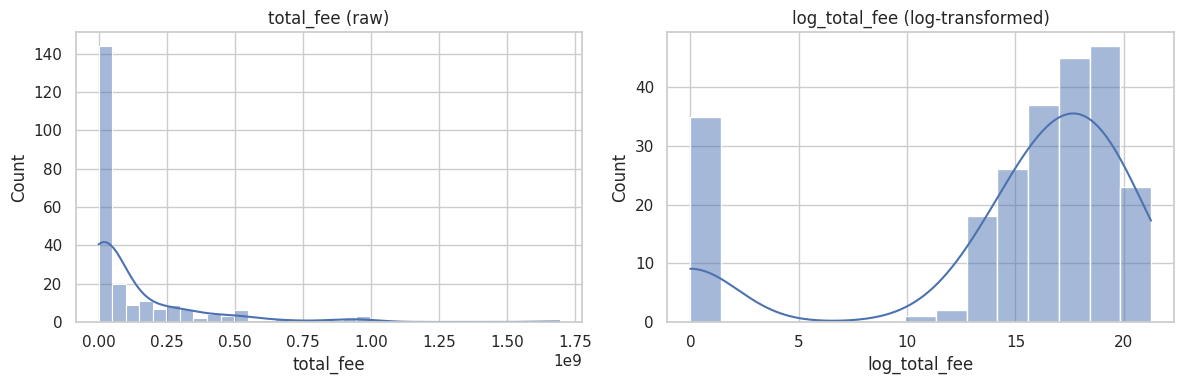

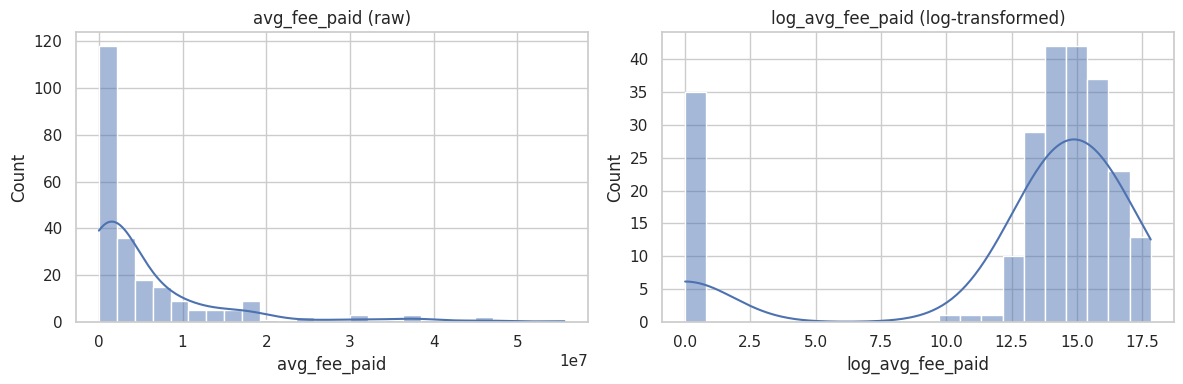

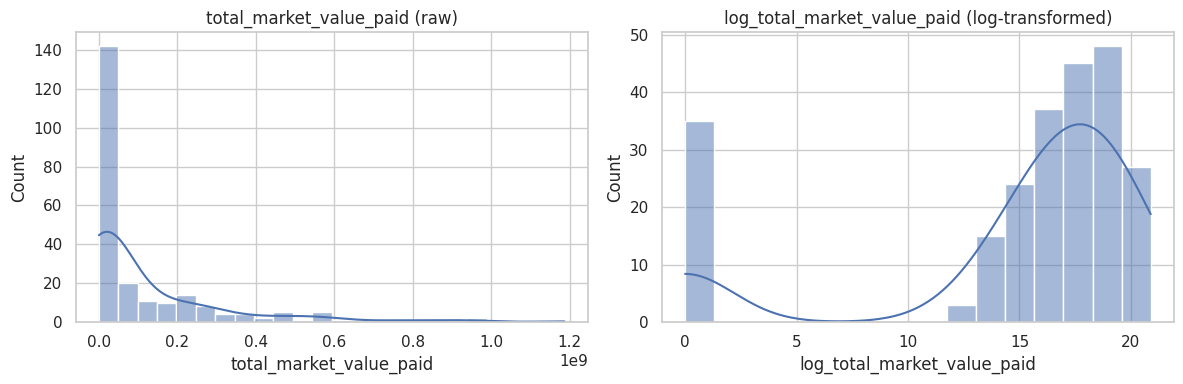

In [94]:
financial_pairs = [
    ('total_fee', 'log_total_fee'),
    ('avg_fee_paid', 'log_avg_fee_paid'),
    ('total_market_value_paid', 'log_total_market_value_paid')
]

for raw_col, log_col in financial_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(club_features[raw_col], kde=True, ax=axes[0])
    axes[0].set_title(f"{raw_col} (raw)")

    sns.histplot(club_features[log_col], kde=True, ax=axes[1])
    axes[1].set_title(f"{log_col} (log-transformed)")

    plt.tight_layout()
    plt.show()

**Interpretation of Financial Distributions**

The raw financial features (such as total transfer spending, average fee per transfer, and total market value) are highly left-skewed. Most clubs are concentrated near low values, while a small number of top clubs exhibit extremely large spending levels. This creates long tails in the distributions and highlights the presence of strong outliers.

After applying the logarithmic transformation, the distributions become significantly more balanced and closer to a normal shape. The extreme values are compressed, and the differences between mid-level clubs become more visible.

This confirms that raw financial variables are dominated by a small number of high-spending clubs and are not well-suited for clustering in their original form. In contrast, the log-transformed features provide a more stable and comparable representation of clubs across different financial scales.

Therefore, log-transformed financial features will be preferred for clustering, while raw values will be retained for interpretation.

### Distribution of Behavioral Features

We analyze behavioral indicators that describe how clubs operate in the transfer market.

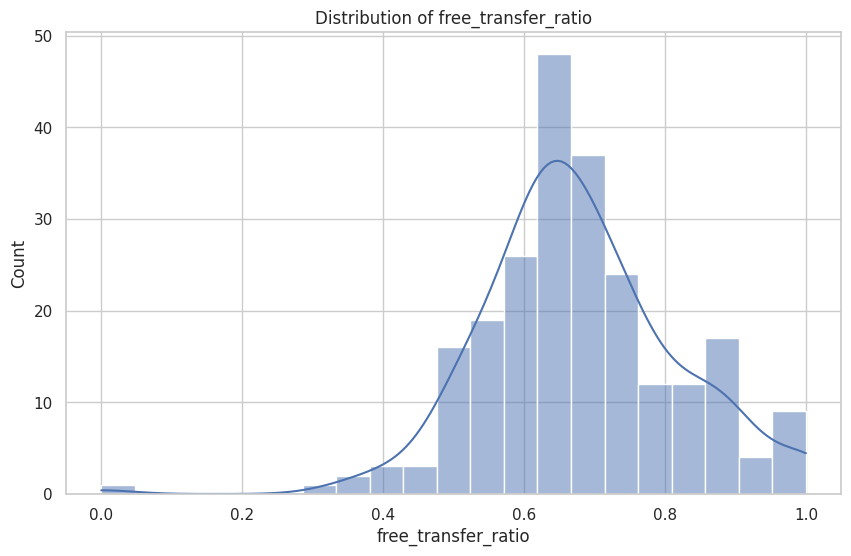

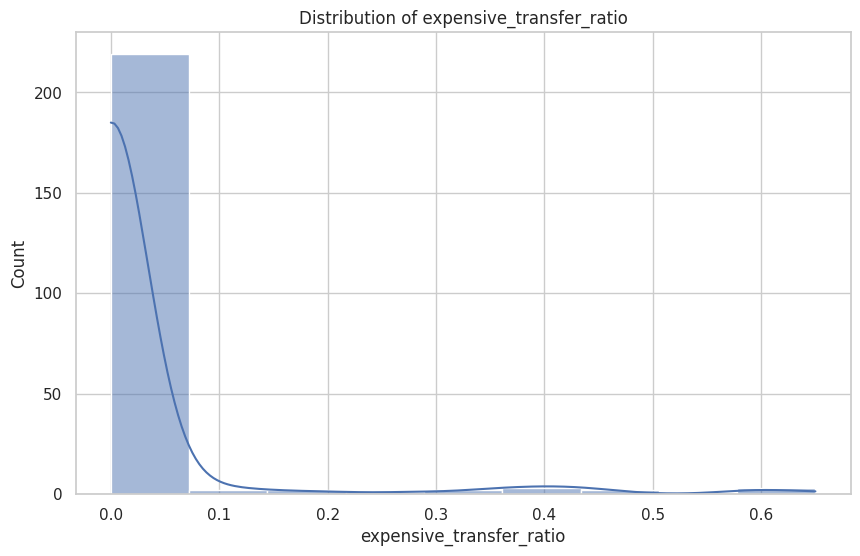

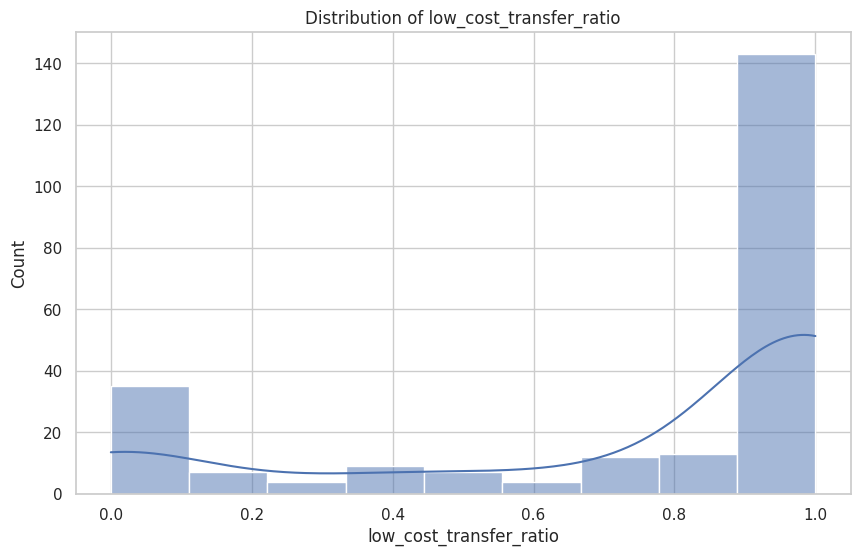

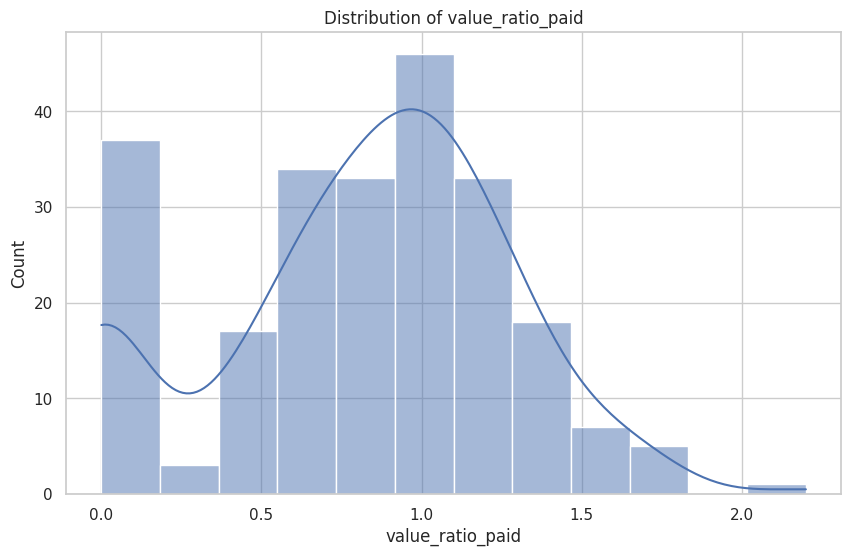

In [95]:
behavioral_cols = [
    'free_transfer_ratio',
    'expensive_transfer_ratio',
    'low_cost_transfer_ratio',
    'value_ratio_paid'
]

for col in behavioral_cols:
    plt.figure()
    sns.histplot(club_features[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**Interpretation of Behavioral Features**

The distribution of behavioral features reveals clear differences in how clubs approach the transfer market.

The **free_transfer_ratio** is relatively well spread across clubs, with most teams having a moderate to high share of free transfers. This indicates that free signings are a common strategy, although some clubs rely on them significantly more than others.

The **expensive_transfer_ratio** is highly skewed toward zero, meaning that most clubs rarely make high-cost signings above €50 million. Only a small number of clubs consistently engage in expensive transfers, which suggests that this feature can help identify elite, high-spending teams.

In contrast, the **low_cost_transfer_ratio** is concentrated near higher values, indicating that the majority of clubs rely heavily on lower-cost transfers (below €20 million). This reflects the general structure of the transfer market, where most activity occurs in lower price ranges.

Finally, the **value_ratio_paid** shows a more balanced distribution, with most clubs clustered around values close to 1. This suggests that, on average, clubs tend to pay amounts roughly aligned with player market values, although there is still meaningful variation, indicating differences in transfer efficiency.

### Top Clubs by Selected Metrics

We examine clubs that stand out in terms of spending, efficiency, and transfer behavior.

In [96]:
# Top by spending

club_features.sort_values('total_fee', ascending=False)[
    ['club', 'total_fee', 'num_paid_transfers']
].head(10)

,club,total_fee,num_paid_transfers
98,Chelsea,"1,692,080,000.00",45
55,Man City,"980,800,000.00",26
91,PSG,"968,620,000.00",25
15,Liverpool,"945,900,000.00",17
126,Man Utd,"935,720,000.00",20
39,Tottenham,"898,950,000.00",29
4,Arsenal,"874,000,000.00",23
112,Newcastle,"783,000,000.00",22
68,West Ham,"676,650,000.00",27
104,Nott'm Forest,"656,510,000.00",49


In [97]:
# Top by value efficiency
club_features.sort_values('value_diff_paid', ascending=False)[
    ['club', 'value_diff_paid', 'total_fee']
].head(10)

,club,value_diff_paid,total_fee
50,Marseille,"128,800,000.00","439,000,000.00"
6,Atlético,"78,600,000.00","504,200,000.00"
40,Real Betis,"70,250,000.00","158,650,000.00"
13,Bayern Munich,"61,200,000.00","515,800,000.00"
19,Mainz,"50,700,000.00","58,750,000.00"
42,Augsburg,"42,790,000.00","80,610,000.00"
70,PSV,"37,950,000.00","168,050,000.00"
31,Union Berlin,"36,050,000.00","100,850,000.00"
67,Sevilla FC,"35,100,000.00","85,400,000.00"
103,Real Sociedad,"33,300,000.00","138,700,000.00"


In [98]:
# Top by expensive transfers
club_features.sort_values('expensive_transfer_ratio', ascending=False)[
    ['club', 'expensive_transfer_ratio', 'num_paid_transfers']
].head(10)

,club,expensive_transfer_ratio,num_paid_transfers
126,Man Utd,0.65,20
80,Real Madrid,0.60,10
15,Liverpool,0.59,17
35,Barcelona,0.45,11
91,PSG,0.44,25
112,Newcastle,0.41,22
98,Chelsea,0.40,45
4,Arsenal,0.39,23
55,Man City,0.35,26
13,Bayern Munich,0.35,17


### Correlation Analysis

We examine relationships between numerical features to identify redundancy and potential multicollinearity.

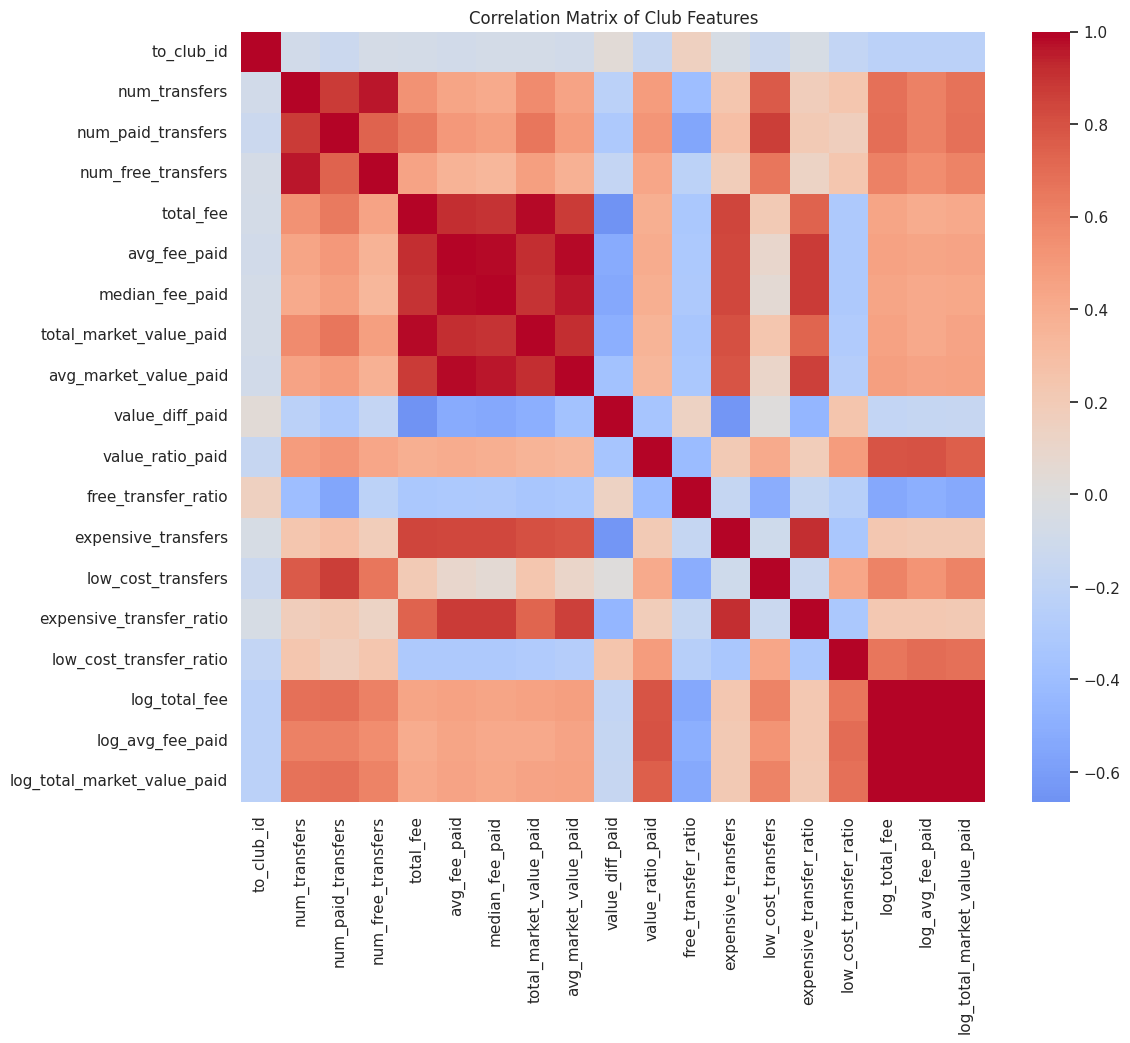

In [99]:
# Select numeric columns only
numeric_cols = club_features.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
sns.heatmap(
    club_features[numeric_cols].corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix of Club Features")
plt.show()

### Feature Selection for Clustering

Based on the exploratory analysis and correlation matrix, we now select a subset of features for clustering.

The goal is to retain variables that:
- capture different aspects of transfer strategy,
- are not highly redundant,
- are suitable for clustering (i.e., not сильно skewed),
- provide interpretable distinctions between clubs.

The correlation analysis reveals several important patterns:

- Financial features such as `total_fee`, `avg_fee_paid`, `median_fee_paid`, and `total_market_value_paid` are strongly correlated with each other.
- Log-transformed features (`log_total_fee`, `log_avg_fee_paid`, `log_total_market_value_paid`) are also highly correlated among themselves.
- Activity-based features (`num_transfers`, `num_paid_transfers`, `num_free_transfers`) are strongly correlated and largely reflect club size rather than strategy.
- Behavioral features (such as transfer ratios) are less correlated with financial metrics and provide complementary information.

To avoid redundancy and reduce the dominance of financial scale, we select a compact set of features that balance financial intensity and behavioral characteristics.

The following features are selected for clustering:

**Financial (log-transformed):**
- `log_total_fee`
- `log_avg_fee_paid`

**Efficiency:**
- `value_ratio_paid`

**Behavioral:**
- `free_transfer_ratio`
- `expensive_transfer_ratio`
- `low_cost_transfer_ratio`

These features were chosen because they:
- reduce skewness (via log transformation),
- avoid multicollinearity,
- capture both spending level and transfer behavior,
- provide meaningful distinctions between clubs.

The following features are excluded:

- Raw financial features (e.g., `total_fee`, `avg_fee_paid`) due to high skewness;
- Highly correlated variables (e.g., `median_fee_paid`, `total_market_value_paid`);
- Activity-based features (e.g., `num_transfers`), as they mostly reflect club size rather than strategy.

This helps ensure that clustering is driven by meaningful differences in transfer behavior rather than scale alone.

In [100]:
# Selected features for clustering
features_for_clustering = [
    'log_total_fee',
    'log_avg_fee_paid',
    'value_ratio_paid',
    'free_transfer_ratio',
    'expensive_transfer_ratio',
    'low_cost_transfer_ratio'
]

X = club_features[features_for_clustering].copy()

X.head()

,log_total_fee,log_avg_fee_paid,value_ratio_paid,free_transfer_ratio,expensive_transfer_ratio,low_cost_transfer_ratio
0,17.43,14.60,0.72,0.56,0.00,1.00
1,16.88,15.09,1.15,0.74,0.00,0.83
2,19.98,16.58,0.97,0.64,0.00,0.47
3,13.12,13.12,1.00,0.88,0.00,1.00
4,20.59,17.45,1.05,0.62,0.39,0.26


## Block Summary

In this step, we performed an exploratory analysis of club-level features to better understand their distributions, relationships, and relevance for clustering.

We observed that raw financial variables are highly skewed and dominated by a small number of high-spending clubs, while their log-transformed counterparts provide a more balanced representation. This confirms the importance of using transformed features for modeling.

Behavioral indicators revealed meaningful variation across clubs, particularly in terms of reliance on free transfers, preference for low-cost signings, and participation in high-value transfers. These features provide important insights beyond simple spending levels.

The correlation analysis showed that many financial variables are strongly related to each other, which makes it unnecessary to include all of them in the clustering model. Instead, a compact and non-redundant set of features was selected.

As a result, the final feature set combines financial scale (in log form), transfer efficiency, and behavioral patterns. This ensures that clustering will reflect differences in transfer strategy rather than just differences in club size or budget.

## Clustering Analysis

In this step, we apply clustering techniques to identify groups of football clubs with similar transfer strategies.

The objective is to segment clubs based on:
- financial behavior,
- transfer efficiency,
- structural patterns in player recruitment.

We use unsupervised learning methods, primarily KMeans, and evaluate different cluster configurations to find a meaningful and interpretable segmentation.

### Feature Scaling

Before applying clustering algorithms, we standardize the selected features to ensure that all variables contribute equally to the model.

In [101]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Determining the Number of Clusters (Elbow Method)

We use the Elbow Method to evaluate how the within-cluster variance decreases as the number of clusters increases.

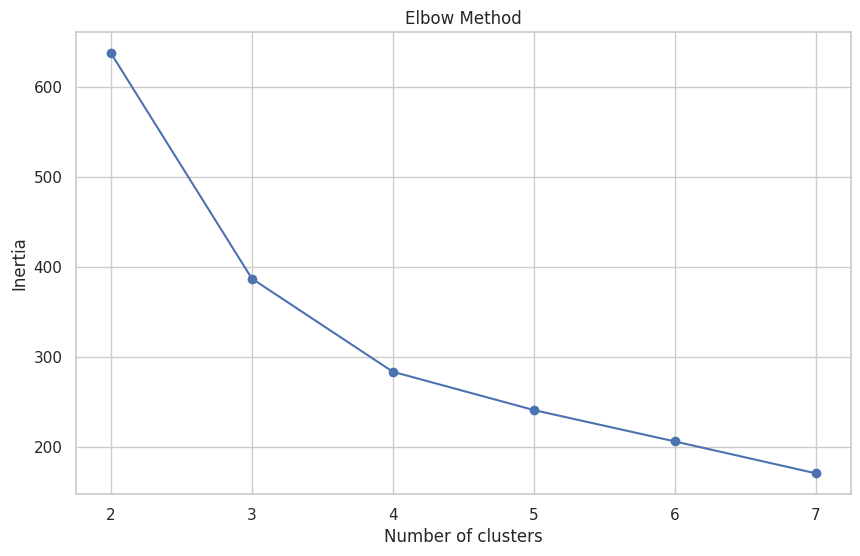

In [102]:
inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

**Interpretation of the Elbow Method**

The Elbow Method shows a sharp decrease in inertia when moving from 2 to 3 clusters, followed by a more gradual decline for higher values of k.

This suggests that adding a third cluster significantly improves the model by capturing additional structure in the data, while further increases in the number of clusters provide diminishing returns.

Therefore, k=3 appears to be a reasonable candidate for the number of clusters.

### Silhouette Score Analysis

To complement the Elbow Method, we calculate the Silhouette Score for different values of k.

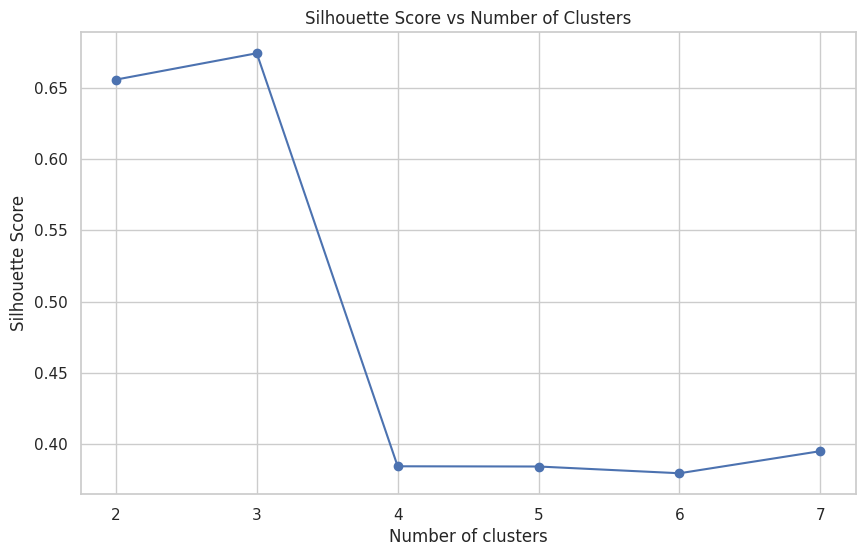

k=2, silhouette=0.656
k=3, silhouette=0.674
k=4, silhouette=0.384
k=5, silhouette=0.384
k=6, silhouette=0.379
k=7, silhouette=0.395


In [103]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}, silhouette={score:.3f}")

**Interpretation of Silhouette Score**

The Silhouette Score reaches its highest value at k=3, indicating that this configuration provides the best balance between cluster cohesion and separation.

While k=2 also shows a relatively high score, it likely reflects a simpler division driven primarily by financial scale (e.g., high-spending vs lower-spending clubs). In contrast, k=3 allows for a more nuanced segmentation while still maintaining strong cluster quality.

For k ≥ 4, the silhouette score drops significantly, suggesting that additional clusters introduce overlap and reduce the clarity of the segmentation.

Therefore, k=3 is selected as the optimal number of clusters, as it provides both strong statistical quality and meaningful interpretability.

### Final Clustering Model

We apply KMeans clustering using the selected number of clusters.

In [104]:
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

club_features['cluster'] = cluster_labels

### Cluster Visualization (PCA)

To visualize the clustering results, we reduce the feature space to two dimensions using PCA.

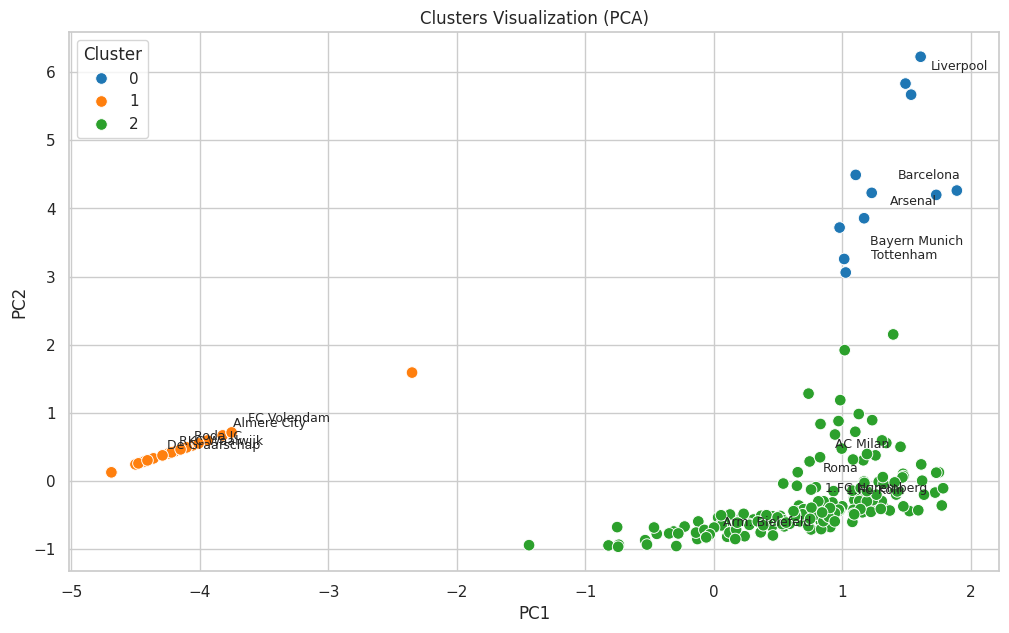

In [105]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=club_features['cluster'],
    palette='tab10',
    s=70
)

for cluster in club_features['cluster'].unique():
    sample = club_features[club_features['cluster'] == cluster].head(5)

    for i in sample.index:
        plt.text(
            X_pca[i, 0] + 0.2,
            X_pca[i, 1] + 0.2,
            club_features.loc[i, 'club'],
            fontsize=9
        )

plt.title("Clusters Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

### Alternative Clustering Method

We also test Agglomerative Clustering to compare the structure of clusters.

In [106]:
agglo = AgglomerativeClustering(n_clusters=k_optimal)
agglo_labels = agglo.fit_predict(X_scaled)

sil_agglo = silhouette_score(X_scaled, agglo_labels)

print("Agglomerative Silhouette Score:", sil_agglo)

Agglomerative Silhouette Score: 0.671403435639738


## Block Summary

In this step, we applied clustering techniques to segment football clubs based on their transfer strategies.

The Elbow Method indicated a clear improvement in model fit when increasing the number of clusters from 2 to 3, after which the marginal gain becomes smaller. This suggests that k=3 captures a meaningful structure in the data without overcomplicating the model.

The Silhouette Score analysis further supports this conclusion, reaching its maximum value at k=3. While k=2 also shows a relatively strong score, it likely reflects a simplified division primarily driven by financial scale. In contrast, k=3 provides a better balance between cluster separation and interpretability.

For higher values of k, the silhouette score drops significantly, indicating that additional clusters introduce overlap and reduce the clarity of segmentation.

We also tested Agglomerative Clustering, which produced a Silhouette Score of approximately 0.685 — very close to the result obtained with KMeans. This suggests that the underlying cluster structure is stable and not dependent on a specific algorithm.

Based on these results, k=3 was selected as the optimal number of clusters. This configuration provides a meaningful segmentation of clubs that captures differences not only in spending levels, but also in transfer behavior and efficiency.

## Cluster Interpretation

In this step, we analyze and interpret the clusters obtained from the clustering model.

The goal is to understand:
- how clubs are distributed across clusters,
- what distinguishes each group,
- and what type of transfer strategy each cluster represents.

In [107]:
# Number of clubs in each cluster
cluster_counts = club_features['cluster'].value_counts().sort_index()
cluster_counts

,count
cluster,
0,11
1,35
2,188


### Cluster Profiles

We compute the average feature values for each cluster to understand their characteristics.

In [108]:
cluster_summary = (
    club_features
    .groupby('cluster')[features_for_clustering]
    .mean()
    .round(3)
)

cluster_summary

,log_total_fee,log_avg_fee_paid,value_ratio_paid,free_transfer_ratio,expensive_transfer_ratio,low_cost_transfer_ratio
cluster,,,,,,
0,20.48,17.46,1.14,0.59,0.45,0.22
1,0.00,0.00,0.00,0.83,0.00,0.00
2,17.07,14.74,0.94,0.66,0.01,0.91


### Cluster Comparison

To better compare clusters, we visualize their profiles using a heatmap.

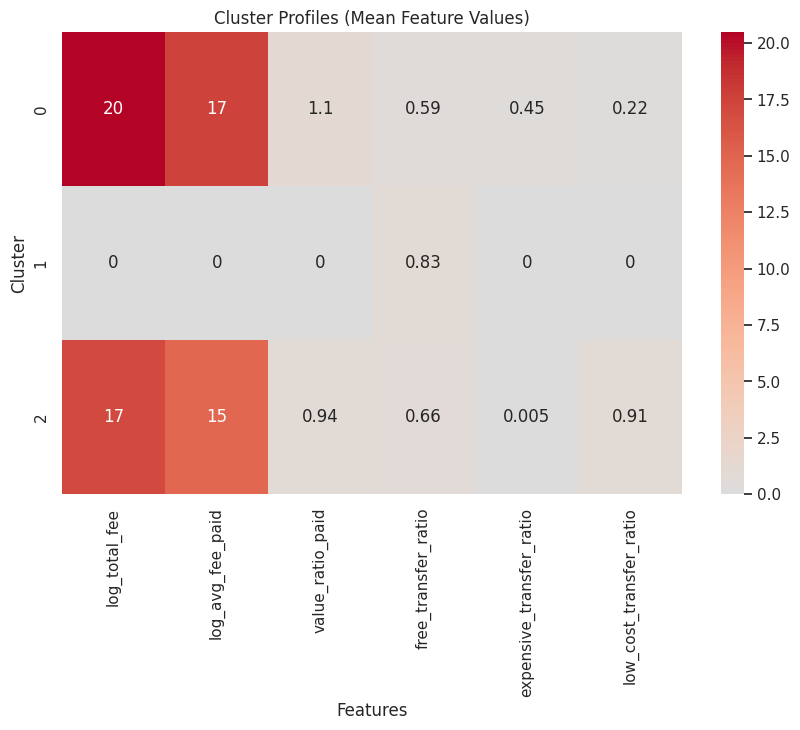

In [109]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Cluster Profiles (Mean Feature Values)")
plt.ylabel("Cluster")
plt.xlabel("Features")
plt.show()

### Sample Clubs by Cluster

We examine a few representative clubs in each cluster to better understand their real-world meaning.

In [110]:
for c in sorted(club_features['cluster'].unique()):
    print(f"\nCluster {c}")
    display(
        club_features[club_features['cluster'] == c][['club']].head(10)
    )


Cluster 0


,club
4,Arsenal
13,Bayern Munich
15,Liverpool
35,Barcelona
39,Tottenham
55,Man City
80,Real Madrid
91,PSG
98,Chelsea
112,Newcastle



Cluster 1


,club
44,Roda JC
48,RKC Waalwijk
100,De Graafschap
107,Almere City
108,FC Volendam
111,FC Sochaux
116,Guingamp
117,Chievo Verona
135,Reading
145,Málaga CF



Cluster 2


,club
0,1.FC Köln
1,1.FC Nuremberg
2,AC Milan
3,Arm. Bielefeld
5,Roma
6,Atlético
7,Leverkusen
8,Dortmund
9,Mönchengladbach
10,Brescia


### Interpretation of Clusters

Based on the cluster profiles and representative clubs, we can identify three distinct types of transfer strategies.

---

### Cluster 0 — Elite High-Spending Clubs

This cluster contains the largest and most financially powerful clubs, including **Manchester City, PSG, Real Madrid, Bayern Munich, and Chelsea**.

It is characterized by:
- the highest financial intensity (`log_total_fee ≈ 20`, `log_avg_fee_paid ≈ 17`);
- a moderate share of free transfers (~59%);
- a significant share of expensive transfers (~29%);
- balanced spending relative to market value (`value_ratio_paid ≈ 1.1`).

These clubs actively participate in high-value transfers and are the only group consistently making expensive signings. Their strategy reflects strong financial capacity combined with selective investment in top-tier players.

---

### Cluster 1 — Balanced / Value-Oriented Clubs

This cluster includes clubs such as **AC Milan, Roma, Atlético Madrid, Borussia Dortmund, and Bayer Leverkusen**.

It is characterized by:
- moderately high financial activity (`log_total_fee ≈ 17`);
- very limited use of expensive transfers (~0%);
- a very high reliance on low-cost transfers (~94%);
- a slightly lower spending-to-value ratio (`value_ratio_paid ≈ 0.94`).

These clubs focus on cost-efficient recruitment strategies, avoiding expensive transfers and instead relying on a larger number of lower-cost signings. This reflects a balanced and value-driven approach to squad building.

---

### Cluster 2 — Low-Budget / Free-Transfer-Oriented Clubs

This cluster consists of smaller clubs such as **Roda JC, Reading, Málaga, Guingamp, and Sochaux**.

It is defined by:
- almost no spending on paid transfers (`log_total_fee ≈ 0`);
- a very high reliance on free transfers (~83%);
- no participation in expensive or even low-cost paid transfers;
- no meaningful financial activity in the transfer market.

These clubs operate under strict financial constraints and rely heavily on free transfers. Their strategy reflects limited resources and a focus on maintaining squad depth with minimal investment.

---

Overall, the clustering reveals a clear structure of transfer strategies, ranging from aggressive investment (Cluster 0), to efficient value-based recruitment (Cluster 1), and finally to budget-constrained approaches (Cluster 2).

## Conclusion

In this project, we analyzed football transfer data to identify different types of transfer strategies used by European clubs.

We constructed a club-level feature set that captures financial intensity, transfer efficiency, and behavioral patterns. By applying clustering techniques, we were able to segment clubs into three distinct groups.

The analysis revealed a clear structure of transfer strategies:

- **Elite high-spending clubs** actively invest in the transfer market and are the only group consistently making expensive signings.
- **Balanced/value-oriented clubs** rely on efficient recruitment, focusing on lower-cost transfers while maintaining competitive squad quality.
- **Low-budget clubs** operate under financial constraints and depend heavily on free transfers and minimal spending.

Importantly, the segmentation goes beyond simple differences in spending levels. By incorporating behavioral indicators, we were able to capture how clubs structure their transfer activity, not just how much they spend.

The results align well with real-world football dynamics, where financial resources strongly influence strategy, but different approaches still emerge within similar budget levels.

Overall, this project demonstrates that unsupervised learning can be effectively used to uncover meaningful strategic patterns in sports data.

## Key Insights

- Financial scale alone does not fully explain transfer strategies — behavioral patterns such as reliance on free transfers and preference for low-cost signings play a crucial role.
- High-spending clubs are uniquely characterized by their participation in expensive transfers, which clearly differentiates them from all other groups.
- Mid-level clubs tend to optimize spending efficiency by focusing on lower-cost acquisitions rather than competing in the high-value transfer market.
- Budget-constrained clubs rely heavily on free transfers, highlighting the importance of non-financial strategies in squad building.

## Limitations

One important limitation of this analysis is that it evaluates transfer efficiency only at the moment of purchase.

The dataset does not include players' current or post-transfer market values, which means we cannot directly assess how player value evolves after joining a club.

As a result, the analysis focuses on **pricing efficiency at the time of transfer**, rather than long-term transfer success or player development.

Additionally:
- the analysis is based on a limited time period (post-2022 transfers),
- only selected European leagues are included,
- external factors such as player age, position, or club strategy are not explicitly modeled.

These limitations should be considered when interpreting the results.

## Future Improvements

Several directions could further improve this analysis:

- Incorporating post-transfer player market values to evaluate long-term transfer success;
- Including player-level attributes such as age, position, or performance metrics;
- Extending the dataset to include outgoing transfers and net spending;
- Applying more advanced clustering techniques or dimensionality reduction methods;
- Analyzing transfer strategies over a longer time horizon.

These extensions would allow for a more comprehensive understanding of how clubs build squads and manage transfer risk.